# Ferrari Stock Prediction

This dataset is downloaded from kaggle (https://www.kaggle.com/datasets/alehcleal/ferrari-stock-data-2015-2026), which contains historical stock market data for Ferrari N.V.(RACE), covering daily trading activity from October 2015 to February 2026.

In our project, we target to predict the future closing prices of Ferrari Stock, modeling ARIMAX and LSTM respectively.

## Data Preparation

Read Ferrari History Stock Data.csv, and print info and description of columns.

In [ ]:
!pip install pmdarima -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 5.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

from statsmodels.tsa.seasonal import seasonal_decompose

from pmdarima.arima import auto_arima

%matplotlib inline

In [ ]:
# Mount Google Drive
from google.colab import drive

# permission to access my Google Drive
drive.mount('/content/drive')
# reading medical_insurance.csv
df=pd.read_csv('/content/drive/MyDrive/COMP_5152/Ferrari History Stock Data.csv')

Mounted at /content/drive


### Initial Data Examination

In [ ]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2015-10-21,50.845524,56.364575,50.845524,55.467844,22498800
1,2015-10-22,52.463337,53.803811,51.492650,52.759165,4545100
2,2015-10-23,52.121284,53.618915,52.019593,53.406289,1967600
3,2015-10-26,50.864014,52.694452,50.420271,52.694452,1466300
4,2015-10-27,49.782391,50.836283,45.631549,50.660632,5949200


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2598 entries, 0 to 2597
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2598 non-null   object 
 1   Close   2598 non-null   float64
 2   High    2598 non-null   float64
 3   Low     2598 non-null   float64
 4   Open    2598 non-null   float64
 5   Volume  2598 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 121.9+ KB


There are 6 columns, 2598 rows in dataset.

* Date: trading date from 2015.10 to 2026.2

* Close: daily closing price

* High: daily highest price

* Low: daily lowest price

* Open: daily opening price

* Volume: the total number of shares traded on that date

In [ ]:
df.describe()

,Close,High,Low,Open,Volume
count,2598.000000,2598.000000,2598.000000,2598.000000,2.598000e+03
mean,212.158698,213.889960,210.419942,212.154888,4.709579e+05
std,132.058569,132.996605,131.097749,132.057662,6.197347e+05
min,29.582851,30.026594,29.268533,29.850947,5.380000e+04
25%,113.411070,114.653173,112.025279,113.923913,2.474000e+05
50%,185.648178,188.069001,183.788222,185.737501,3.504000e+05
75%,297.204849,298.811653,295.464965,296.458131,5.191250e+05
max,517.650024,519.099976,514.830017,515.000000,2.249880e+07


According to the statistical information, no significant outliers were detected.

In [ ]:
missing = df.isnull().sum()
print("Missing Values:")
# print the column name and number of null value
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")

Missing Values:
No missing values


No missing values need to be handled.

Temporal Features: capture market seasonality.

* DayOfWeek & Month: To identify recurring weekly/monthly cycles.

* Is_Quarter_End: To account for institutional rebalancing effects.

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)


# Extract basic time features
df['DayOfWeek'] = df.index.dayofweek
df['Month'] = df.index.month
df['Is_Quarter_End'] = df.index.is_quarter_end.astype(int)

In [ ]:
df.head()

,Close,High,Low,Open,Volume,DayOfWeek,Month,Is_Quarter_End
Date,,,,,,,,
2015-10-21,50.845524,56.364575,50.845524,55.467844,22498800,2,10,0
2015-10-22,52.463337,53.803811,51.492650,52.759165,4545100,3,10,0
2015-10-23,52.121284,53.618915,52.019593,53.406289,1967600,4,10,0
2015-10-26,50.864014,52.694452,50.420271,52.694452,1466300,0,10,0
2015-10-27,49.782391,50.836283,45.631549,50.660632,5949200,1,10,0


## Exploratory Data Analysis

First, plot heatmap to analyze the correlation between target column (Close) and other features.

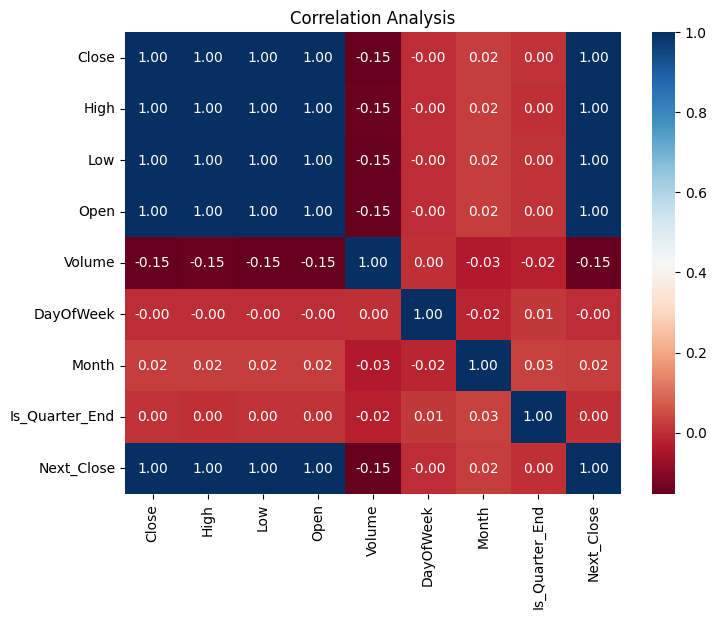

In [ ]:
# predict target: next closing price
df['Next_Close'] = df['Close'].shift(-1)

# heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='RdBu', fmt=".2f")
plt.title("Correlation Analysis")
plt.show()

Due to the extremely high Multi-collinearity of price features, we only use target column (Close) as a representative price indicator in EDA.




In [ ]:
# Calculate Log Return): ln(Pt / Pt-1) * 100
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1)) * 100

# Calculate Relative Volume: MA20
df['Vol_MA20'] = df['Volume'].rolling(window=20).mean()
df['Relative_Volume'] = df['Volume'] / df['Vol_MA20']

df_clean = df.dropna()

### Static Analysis: Distribution and Statistical Properties.

/tmp/ipykernel_5479/948010158.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='DayOfWeek', ax=axes[2, 0], palette='viridis')
/tmp/ipykernel_5479/948010158.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2, 0].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri'])
/tmp/ipykernel_5479/948010158.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Month', ax=axes[2, 1], palette='viridis')


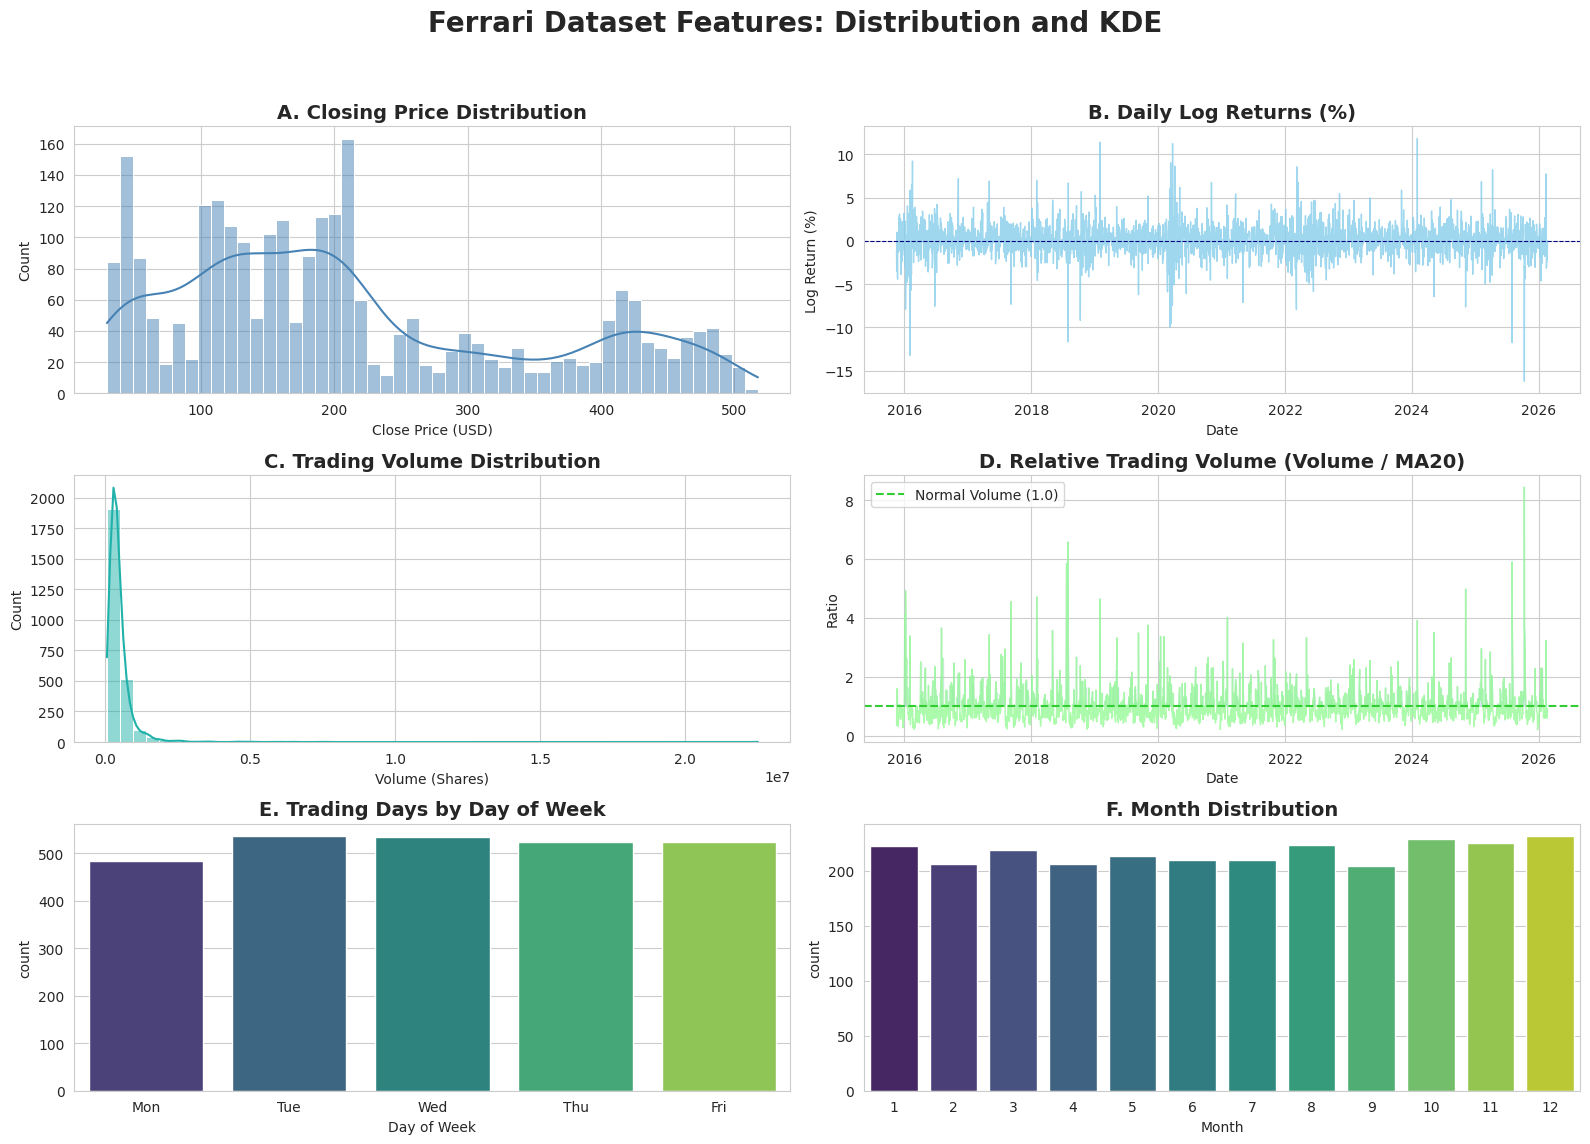

In [ ]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Ferrari Dataset Features: Distribution and KDE', fontsize=20, fontweight='bold')

# 1. Close Price Histplot
sns.histplot(data=df, x='Close', kde=True, ax=axes[0, 0], color='steelblue', bins=50)
axes[0, 0].set_title('A. Closing Price Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Close Price (USD)')

# 2. Daily Return (log)
sns.lineplot(data=df_clean, x=df_clean.index, y='Log_Return', ax=axes[0, 1],
             color='skyblue', linewidth=1, alpha=0.8)
axes[0, 1].axhline(0, color='navy', linestyle='--', linewidth=0.8)
axes[0, 1].set_title('B. Daily Log Returns (%)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Log Return (%)')

# 3. Volume Histplot
sns.histplot(data=df, x='Volume', kde=True, ax=axes[1, 0], color='lightseagreen', bins=50)
axes[1, 0].set_title('C. Trading Volume Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Volume (Shares)')

# 4. Relative Trading Volume
sns.lineplot(data=df_clean, x=df_clean.index, y='Relative_Volume', ax=axes[1, 1],
             color='palegreen', linewidth=1, alpha=0.8)
axes[1, 1].axhline(1, color='limegreen', linestyle='--', linewidth=1.5, label='Normal Volume (1.0)')
axes[1, 1].fill_between(df_clean.index, 1, df_clean['Relative_Volume'],
                 where=(df_clean['Relative_Volume'] > 1), color='steelblue', alpha=0.2)
axes[1, 1].set_title('D. Relative Trading Volume (Volume / MA20)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Ratio')
axes[1, 1].legend()

# 5. Day Of Week Countplot
sns.countplot(data=df, x='DayOfWeek', ax=axes[2, 0], palette='viridis')
axes[2, 0].set_title('E. Trading Days by Day of Week', fontsize=14, fontweight='bold')
axes[2, 0].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri'])
axes[2, 0].set_xlabel('Day of Week')

# 6. Month Countplot
sns.countplot(data=df, x='Month', ax=axes[2, 1], palette='viridis')
axes[2, 1].set_title('F. Month Distribution', fontsize=14, fontweight='bold')
axes[2, 1].set_xlabel('Month')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Analysis:

1.   Closing Price Distribution:

The price data shows a clear multi-peak distribution, with the main peaks occurring around $50, 100, 200, and 400.

This suggests that Ferrari's stock price has not fluctuated around the mean over the past decade, but rather has shown a significant long-term non-stationarity.

Thus, before performing ARIMAX modeling, it is necessary to perform first-order or second-order differencing to eliminate trends.

2.    Daily Return (log):

The Log Returns fluctuate wildly around the 0 axis, showing no average trend over time and demonstrating that the data has achieved stationarity through logarithmic differencing.

Meanwhile, the figure clearly shows that large fluctuations tend to appear in clusters (e.g., the market turmoil at the beginning of 2020). And the plot shows several extreme fluctuations (outliers) exceeding ±10% (e.g., in 2020 and early 2026).

During the evaluation phase, we can examine the model's performance on these dates to analyze its resilience.

3.   Trading Volume Distribution:

The volume distribution is extremely right-skewed. On most days, volume is concentrated at low levels, and there is a long tail extending to the right side of the chart.

The long tail represents a very small number of extremely high-volume days (such as earnings releases or major news events), often corresponding to dramatic stock price reversals.

These points can generate significant MSE (Mean Exchange Rate Score) when evaluating model performance.

4.    Volume / MA20 (Relative Trading Volume):

The dashed line represents the baseline of 1.0 (i.e., the current day's volume equals the average of the past 20 days).

Frequent spikes in the chart (Ratio > 2.0) represent extremely abnormal trading days, typically corresponding to Ferrari's earnings release, major strategic adjustments, or global financial events.

The large fluctuations in Figure B are usually accompanied by high-ratio spikes in Figure D, which proves the logic of volume-price correlation. High relative volume is often a leading signal of price trend reversal or acceleration.

In feature engineering, Relative_Volume is a more effective predictor than the original volume.

5.   Date Distribution (Weekday & Month):

The distribution is very uniform.

This verifies the completeness of the dataset, with no obvious missing data segments, ensuring that model training will not be biased due to missing data in certain time periods.



In [ ]:
df['MA100'] = df['Close'].rolling(100).mean()
df['Volatility100'] = df['Close'].rolling(100).std()

### Dynamic Analysis: Temporal Patterns and Volatility Clusters.

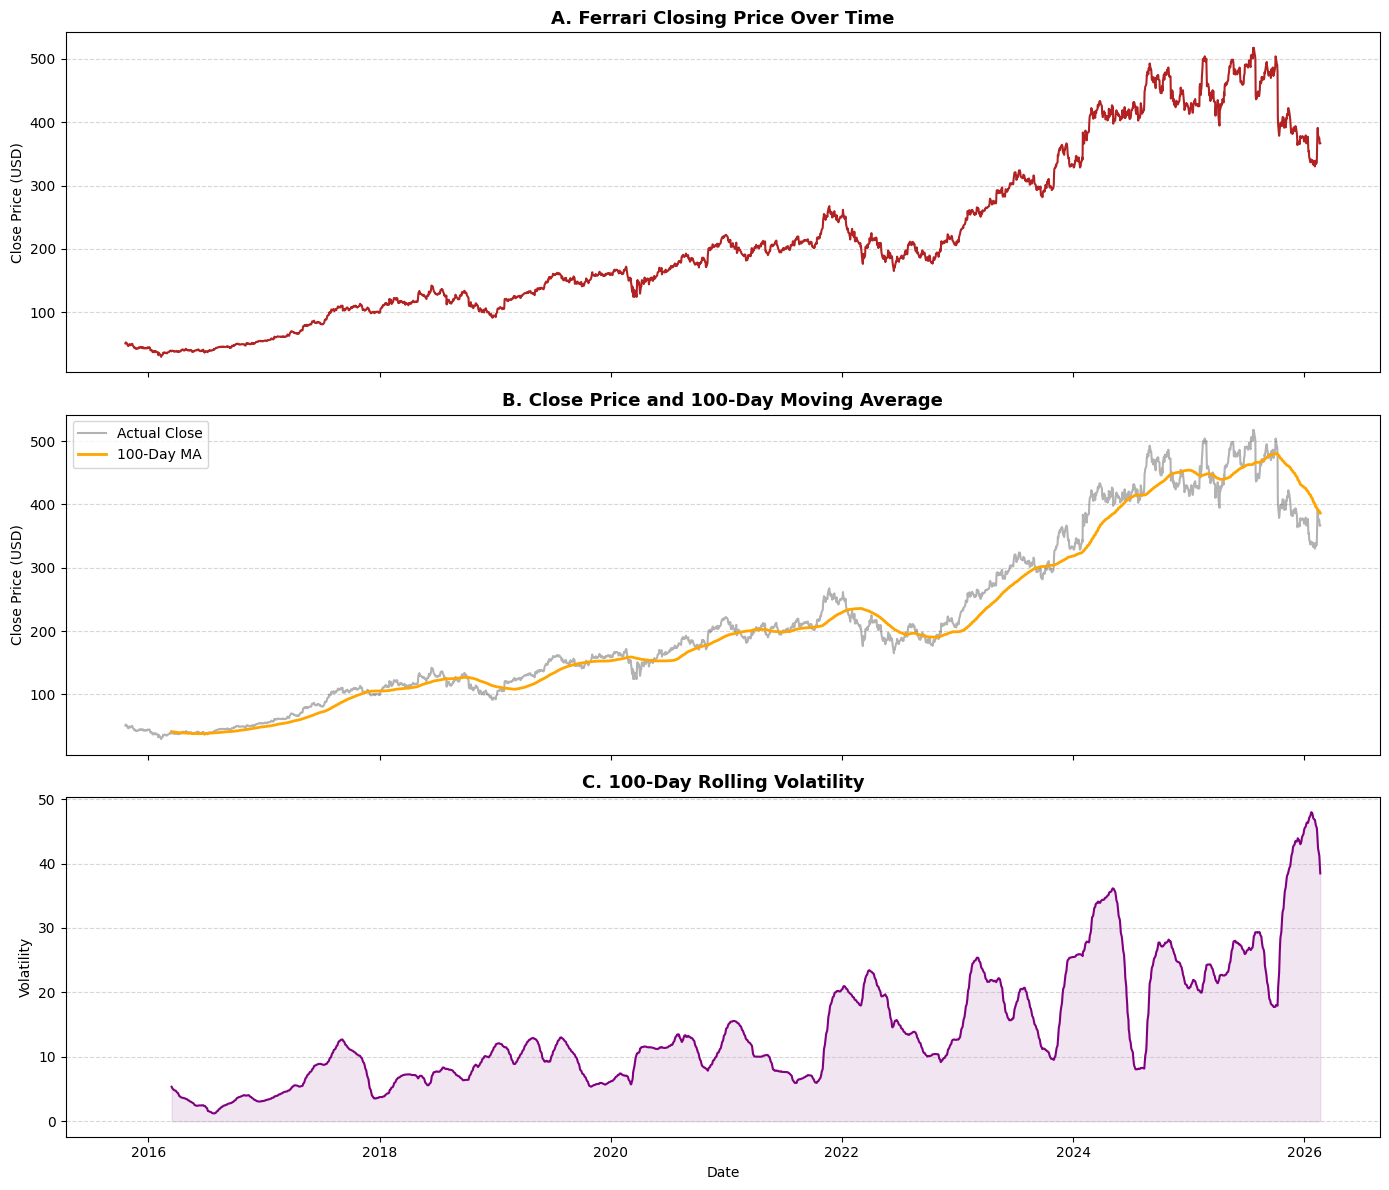

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Ferrari Closing Price Over Time
axes[0].plot(df.index, df['Close'], color='firebrick', linewidth=1.5)
axes[0].set_title('A. Ferrari Closing Price Over Time', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Close Price (USD)')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Close Price and 100-Day Moving Average
axes[1].plot(df.index, df['Close'], color='black', alpha=0.3, label='Actual Close')
axes[1].plot(df.index, df['MA100'], color='orange', linewidth=2, label='100-Day MA')
axes[1].set_title('B. Close Price and 100-Day Moving Average', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Close Price (USD)')
axes[1].legend(loc='upper left')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# 100-Day Rolling Volatility
axes[2].plot(df.index, df['Volatility100'], color='purple', linewidth=1.5)
axes[2].fill_between(df.index, df['Volatility100'], color='purple', alpha=0.1)
axes[2].set_title('C. 100-Day Rolling Volatility', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Volatility')
axes[2].set_xlabel('Date')
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Stationarity Analysis and Diagnostic Testing

In [ ]:
from statsmodels.tsa.stattools import adfuller

# build time series
ts = df[['Close']].copy()
ts['log_close'] = np.log(ts['Close'])

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"ADF Test for {name}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Number of lags used:", result[2])
    print("Number of observations used:", result[3])
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")


# original log series
adf_test(ts['log_close'], 'log_close')

# first difference
ts['diff_log_close'] = ts['log_close'].diff()
adf_test(ts['diff_log_close'], 'diff(log_close)')


ADF Test for log_close
ADF Statistic: -1.3666308321082168
p-value: 0.5981650967329861
Number of lags used: 10
Number of observations used: 2587
Critical Values:
   1%: -3.4328802668982084
   5%: -2.862657875000973
   10%: -2.5673650853551155
ADF Test for diff(log_close)
ADF Statistic: -16.645725391071604
p-value: 1.6201432388638495e-29
Number of lags used: 9
Number of observations used: 2587
Critical Values:
   1%: -3.4328802668982084
   5%: -2.862657875000973
   10%: -2.5673650853551155


The ADF test on log-transformed closing price produced a p-value of 0.5982, indicating that the original series is non-stationary. After first-order differencing, the p-value dropped to 1.62e-29, which is far below 0.05. Therefore, the differenced log closing price series is stationary, and d = 1 is appropriate for the ARIMA model.


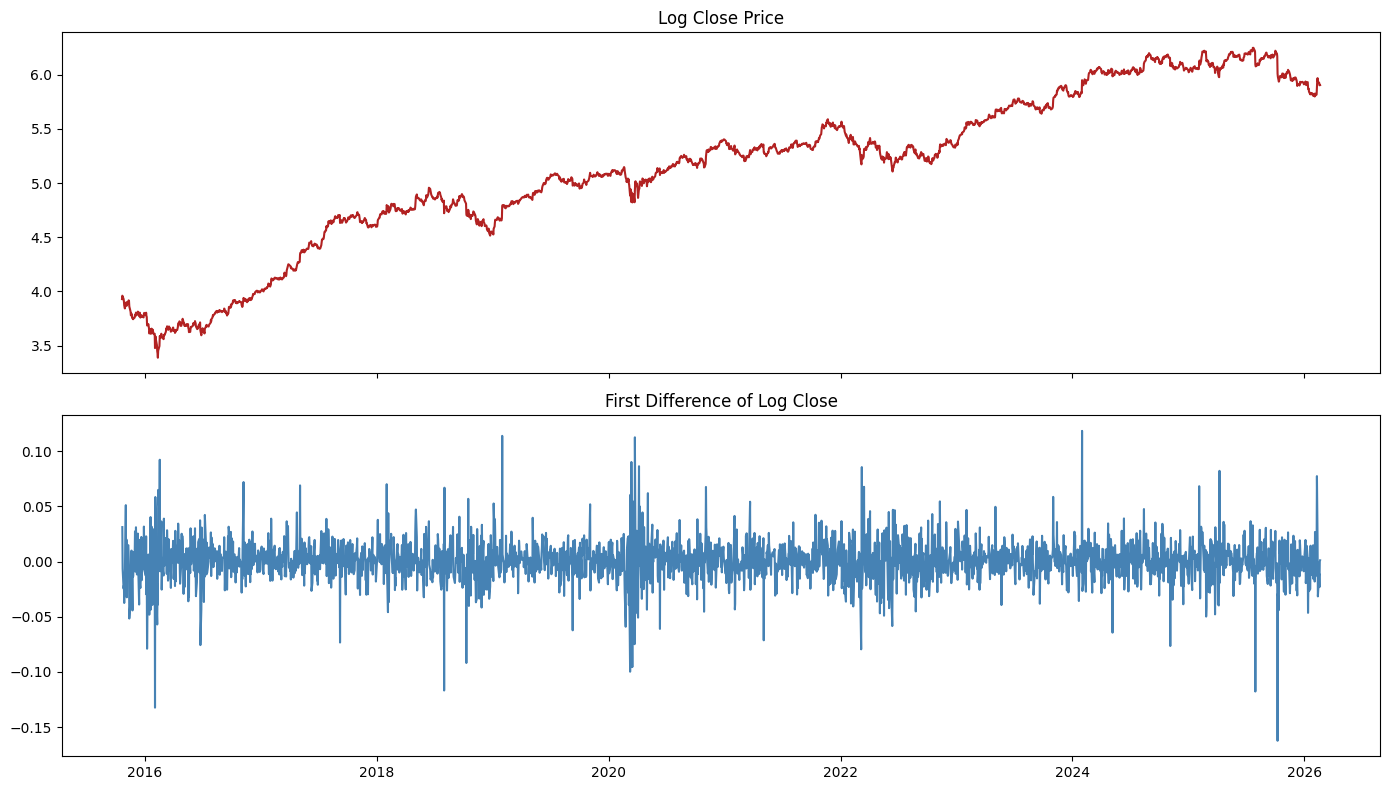

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(ts.index, ts['log_close'], color='firebrick')
axes[0].set_title('Log Close Price')

axes[1].plot(ts.index, ts['diff_log_close'], color='steelblue')
axes[1].set_title('First Difference of Log Close')

plt.tight_layout()
plt.show()


The log-transformed closing price series still shows a clear upward trend, indicating that it remains non-stationary even after logarithmic transformation. After applying first-order differencing, the series fluctuates around zero without an obvious long-term trend, suggesting that stationarity has been substantially improved. However, several large spikes remain, implying that the differenced series still contains periods of elevated volatility.


## Model Training

### LSTM

Long short-term memory (LSTM) is a type of recurrent neural network (RNN) aimed at mitigating the vanishing gradient problem commonly encountered by traditional RNNs.

It aims to provide a short-term memory for RNN that can last thousands of timesteps (thus "long short-term memory"), which is benefit of relative insensitivity to gap length.

1.  Split dataset on 8:2 ratio.

In [ ]:
# create a copy
lstm_df = df.copy()

# calculate log closing price
lstm_df['Target'] = np.log(lstm_df['Close'])
lstm_df['Log_Price_Lag1'] = lstm_df['Target'].shift(1)
lstm_df['Log_Return_Lag1'] = lstm_df['Target'].diff().shift(1)

features_lstm = ['Log_Price_Lag1', 'Log_Return_Lag1', 'Relative_Volume', 'Volatility100']
subset_lstm = lstm_df[features_lstm + ['Target']].dropna()
X_lstm = subset_lstm[features_lstm]
# target: closing price
y_lstm = subset_lstm['Target']

# split on 8:2 ratio
split_idx= int(len(X_lstm) * 0.8)

train_X_raw_lstm = X_lstm.iloc[:split_idx]
train_y_raw_lstm = y_lstm.iloc[:split_idx]
test_X_raw_lstm = X_lstm.iloc[split_idx:]
test_y_raw_lstm = y_lstm.iloc[split_idx:]

Save preprocessed dataset.

In [ ]:
# save dataset (after preprocessing)
subset_lstm.to_csv('/content/drive/MyDrive/COMP_5152/ferrari_preprocessed.csv', index=True)

print("Preprocessed dataset has been saved.")

Preprocessed dataset has been saved.


2.  Scaling target and features.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# prepare scaler
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# fit using training set to prevent data leakage
train_X_scaled = scaler_X.fit_transform(train_X_raw_lstm)
test_X_scaled = scaler_X.transform(test_X_raw_lstm)

# prepare scaler for log_price
train_y_scaled = scaler_y.fit_transform(train_y_raw_lstm.values.reshape(-1, 1))
test_y_scaled = scaler_y.transform(test_y_raw_lstm.values.reshape(-1, 1))

3.   Sliding Window: construct 3D tensor for LSTM model. [number of samples, time step, number of features]

Window size is 30, which means each prediction is based on the log prices of the previous 30 days.

In [ ]:
def create_multivariate_sequences(X_data, y_data, window_size):
    X, y = [], []
    for i in range(window_size, len(X_data)):
        # input (all features)
        X.append(X_data[i - window_size : i, :])
        # target (log_price)
        y.append(y_data[i, 0])

    return np.array(X), np.array(y)

window_size = 30
X_train_lstm, y_train_lstm = create_multivariate_sequences(train_X_scaled, train_y_scaled, window_size)
X_test_lstm, y_test_lstm = create_multivariate_sequences(test_X_scaled, test_y_scaled, window_size)

print(f"X_train shape: {X_train_lstm.shape}") # (..., 30, 4)
print(f"y_train shape: {y_train_lstm.shape}")

X_train shape: (1969, 30, 4)
y_train shape: (1969,)


4.   Construct and train LSTM model.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# LSTM architecture
lstm = Sequential([
    # first layer
    LSTM(units=50, return_sequences=True, input_shape=(window_size, X_train_lstm.shape[2])),
    Dropout(0.2), # apply 20% Dropout to mitigate overfitting

    # second layer
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),

    # Fully connected output layer
    Dense(units=1)
])

# compile model
lstm.compile(optimizer='adam', loss='mean_squared_error')

# early stop
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,          # no progress after 10 rounds of validation
    restore_best_weights=True # return to the best-performing round
)

# train model
history_lstm = lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    shuffle=True,
    validation_split=0.1, # validation
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 0.0277 - val_loss: 0.0051
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0046 - val_loss: 6.4187e-04
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0039 - val_loss: 4.7403e-04
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0033 - val_loss: 3.8940e-04
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0030 - val_loss: 0.0017
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0029 - val_loss: 0.0019
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0027 - val_loss: 0.0012
Epoch 8/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0027 - val_loss: 3.5732e-04
Epoch 9/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0025 - val_loss: 4.6762e-04
Epoch 10/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0025 - val_loss: 0.0016
Epoch 11/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0026 - val_loss: 3.3630e-04
Epoch 12/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 

5.   Predict closing price and evaluate LSTM model.

In [ ]:
# predict log closing price
predict_lstm = lstm.predict(X_test_lstm)

# inverse Transform from 0-1 to Log Scale
y_pred_log = scaler_y.inverse_transform(predict_lstm)
y_test_log = scaler_y.inverse_transform(y_test_lstm.reshape(-1, 1))

# inverse Log from Log Scale to Original Price
y_pred_lstm = np.exp(y_pred_log)
y_test_lstm = np.exp(y_test_log)

y_pred_diff = np.diff(y_pred_lstm.flatten())
y_true_diff = np.diff(y_test_lstm.flatten())

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


In [ ]:
# calculate performance metrics
mse_lstm = mean_squared_error(y_test_lstm, y_pred_lstm)
mae_lstm = mean_absolute_error(y_test_lstm, y_pred_lstm)
rmse_lstm = np.sqrt(mse_lstm)
mape_lstm = mean_absolute_percentage_error(y_test_lstm, y_pred_lstm) * 100
mda_lstm = np.mean(np.sign(y_pred_diff) == np.sign(y_true_diff))


print(f"--- LSTM Model Evaluation ---")
print(f"MAE  : {mae_lstm:.4f} USD")
print(f"MSE  : {mse_lstm:.4f}")
print(f"RMSE : {rmse_lstm:.4f} USD")
print(f"MAPE : {mape_lstm:.4f} %")
print(f"MDA: {mda_lstm:.2%}")

--- LSTM Model Evaluation ---
MAE  : 18.9782 USD
MSE  : 558.3661
RMSE : 23.6298 USD
MAPE : 4.2331 %
MDA: 48.40%


Analysis:

*    The Mean Absolute Error indicates that while the LSTM captures the general price level, it struggles to pinpoint the exact daily closing price amidst high-frequency market noise.


*    The MSE of 558.37 acts as a penalty metric for large forecasting deviations. In the context of Ferrari's volatile price action, a relatively high MSE suggests that the model occasionally suffers from significant 'misses' during abrupt market reversals. This aligns with our earlier observation of volatility clusters, where rapid regime shifts lead to temporary spikes in the squared error.

*    RMSE was 23.63$, slightly higher than the MAE, which indicated the presence of outliers (i.e. certain days where the model's prediction error was substantially larger than average).

*    The MAPE is 4.23% (the model's average prediction error is around 5%). Given the high volatility of Ferrari's stock price between 2024 and 2026, this precision demonstrates the LSTM's robust capability in capturing the long-term mean and overarching price trends.

*    The MDA of 48.40% is slightly below the 50% random benchmark, a representative result for pure price-forecasting models. This reveals a temporal lag effect, where the model tends to predict that tomorrow's price will remain similar to today's, leading to delayed reactions at critical market pivot points.

6.   Visualization.

Compare the original closing price data and prediction.

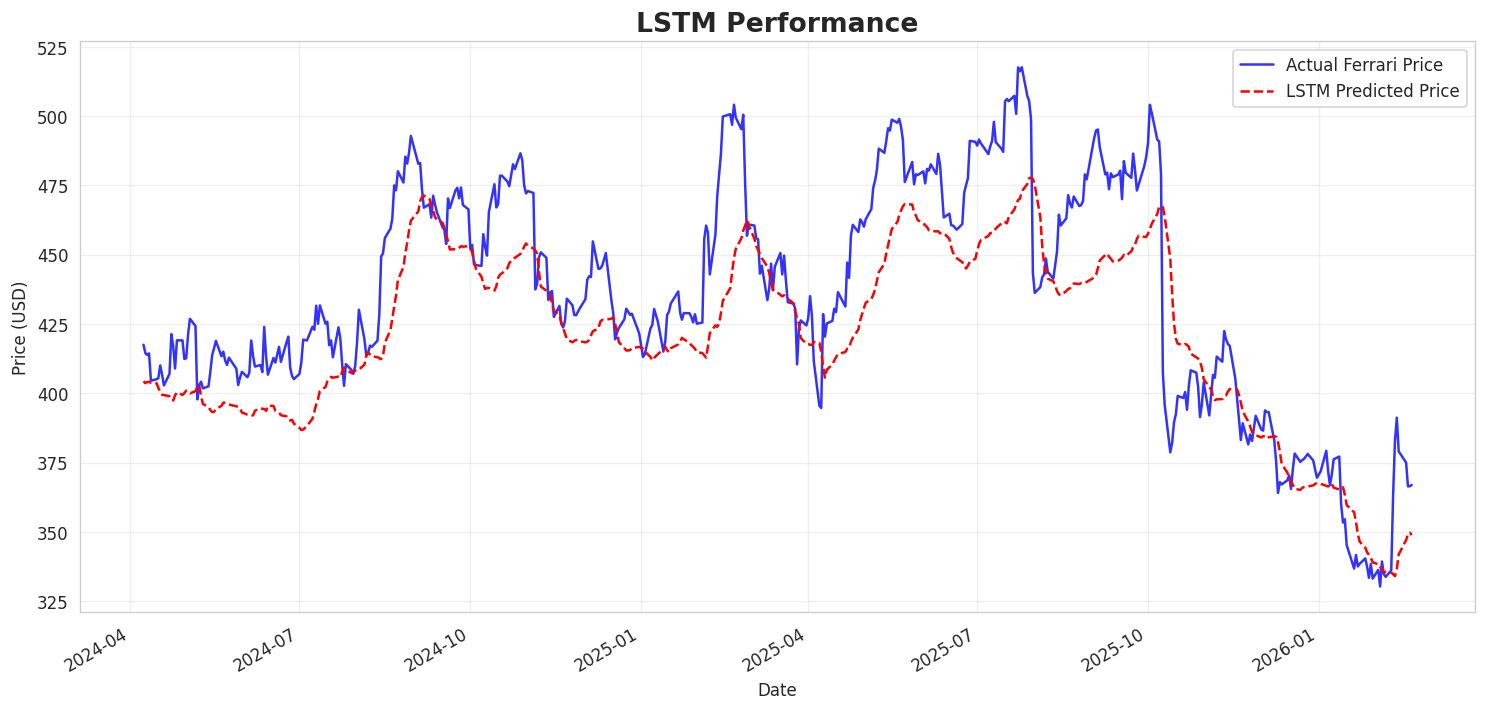

In [ ]:
test_dates = df.index[-len(y_test_lstm):]

plt.figure(figsize=(15, 7), dpi=120)

plt.plot(test_dates, y_test_lstm.flatten(), label='Actual Ferrari Price',
         color='b', linewidth=1.5, alpha=0.8)

plt.plot(test_dates, y_pred_lstm.flatten(), label='LSTM Predicted Price',
         color='r', linestyle='--', linewidth=1.5)

plt.title(f'LSTM Performance', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

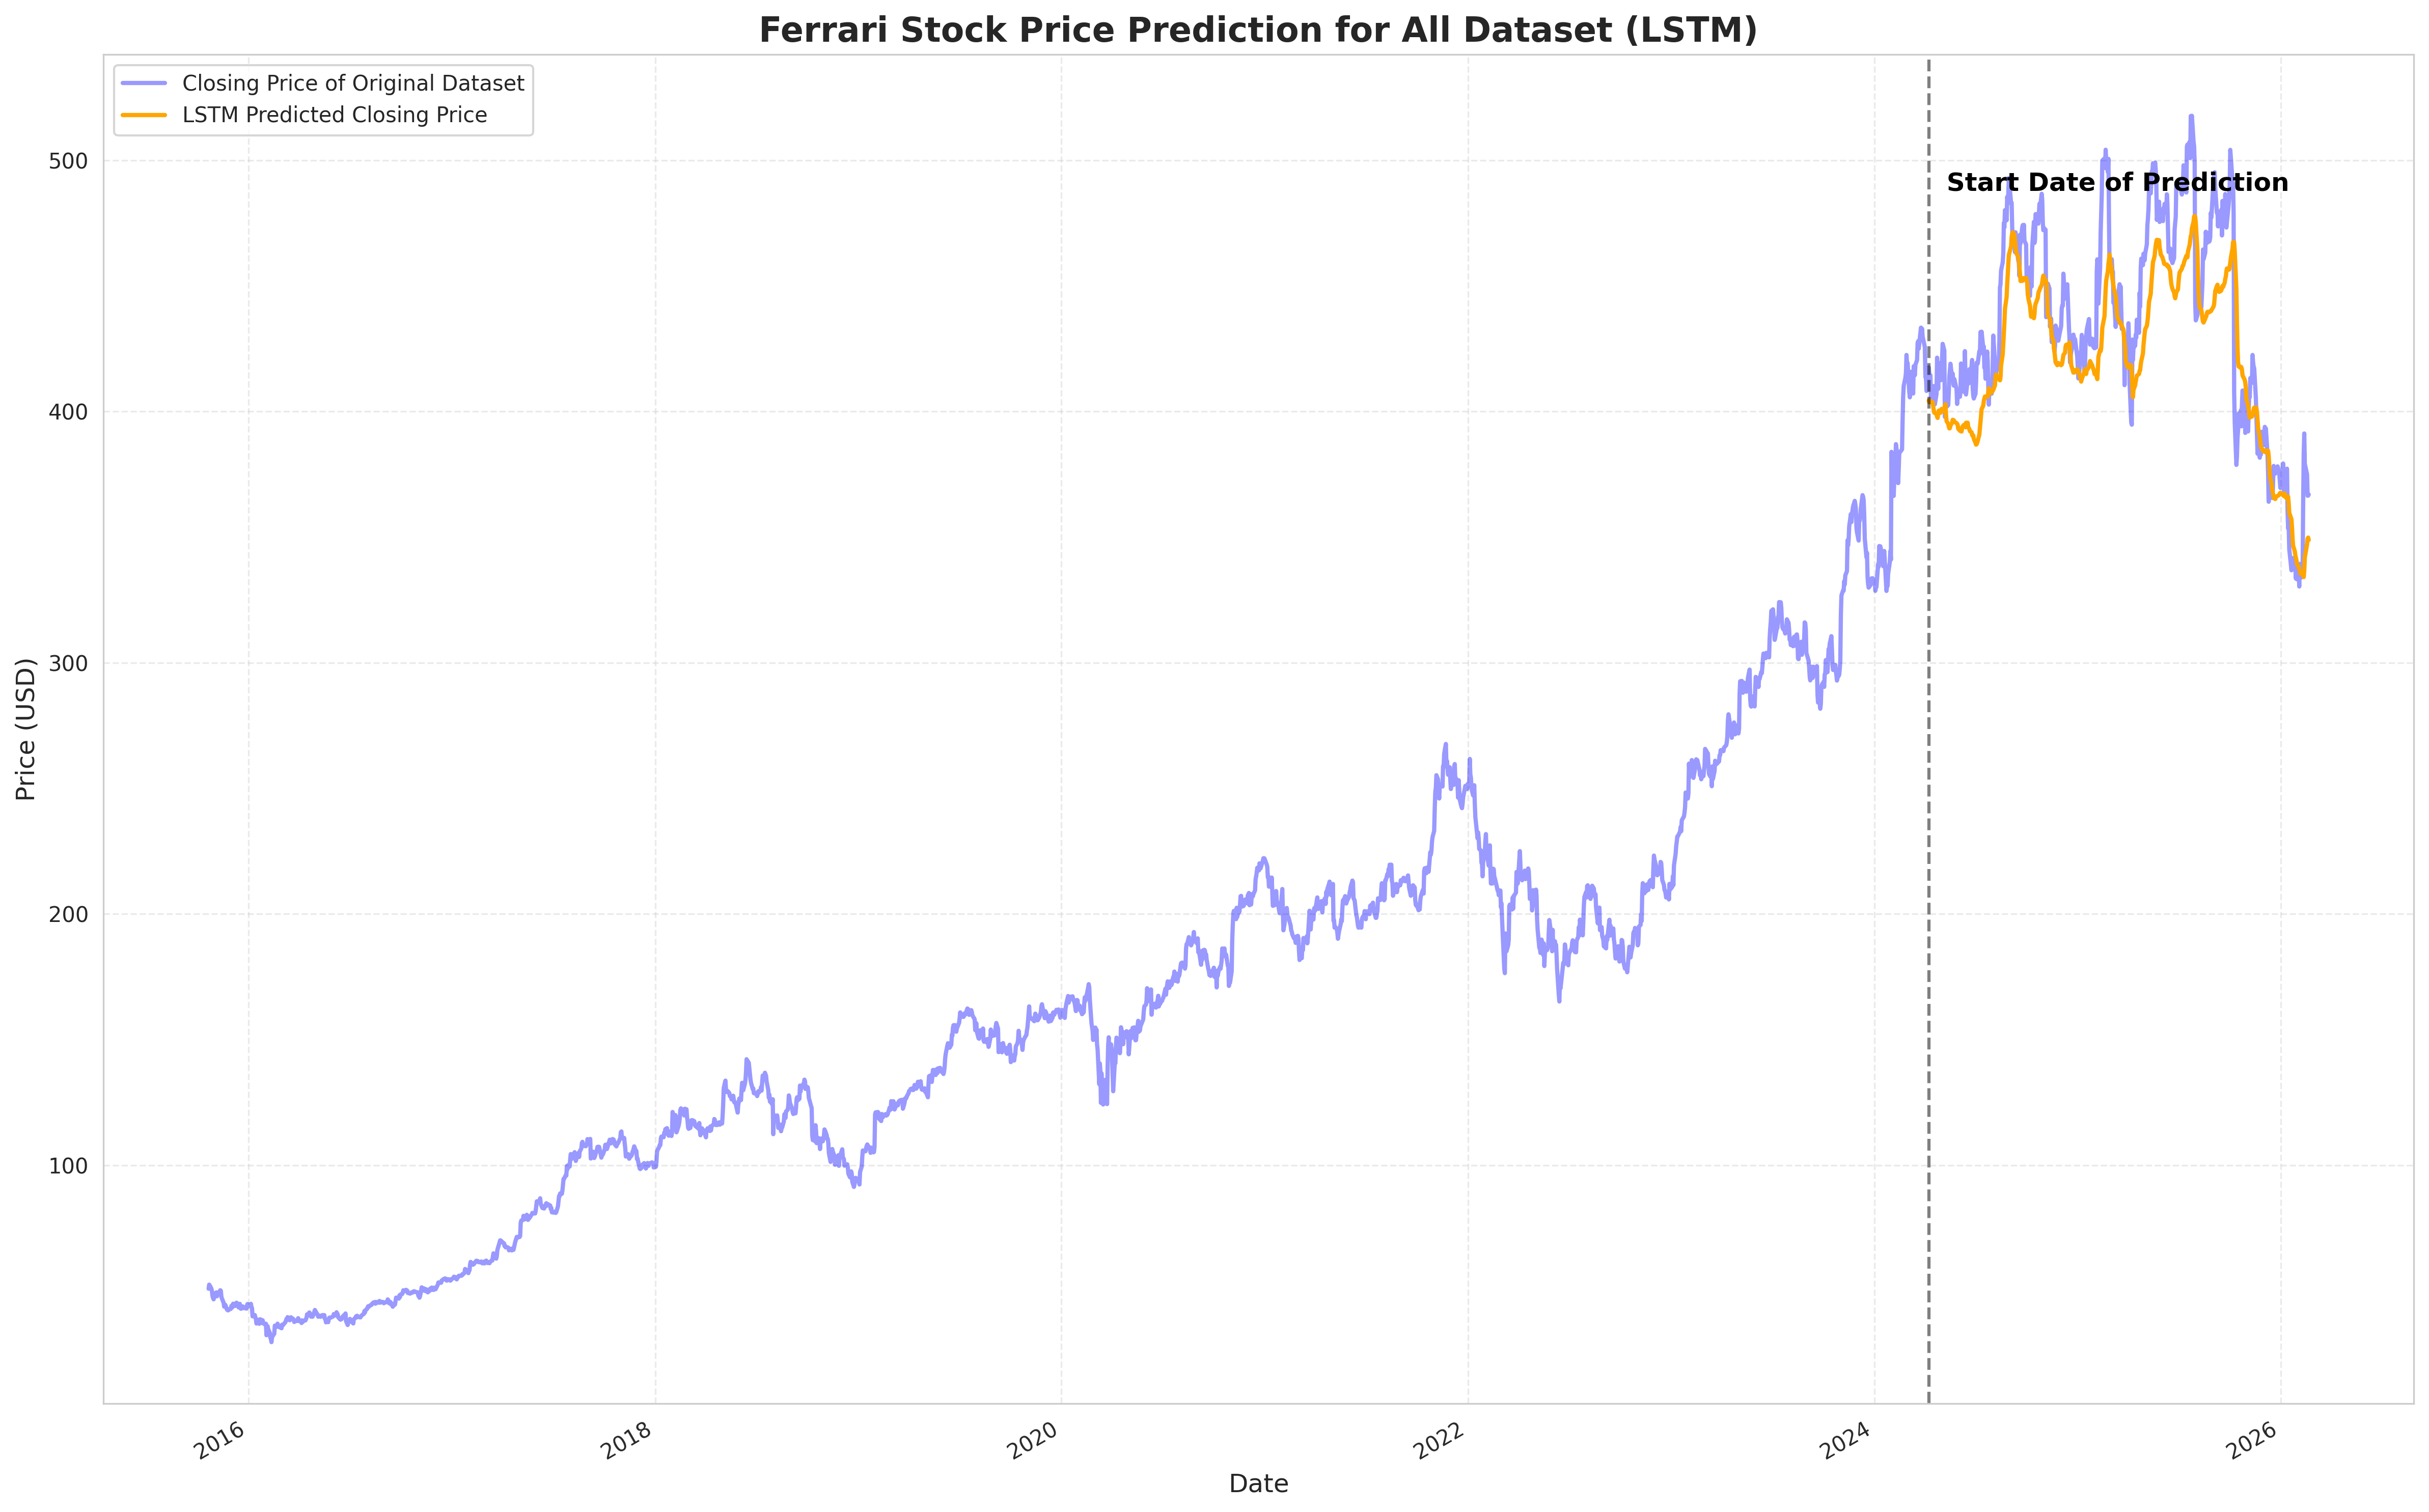

In [ ]:
plt.figure(figsize=(16, 10), dpi=300)

# align Test Set Dates
test_dates = df.index[split_idx:][-len(y_pred_lstm):]

# Close of original dataset
plt.plot(df.index, df['Close'],
         label='Closing Price of Original Dataset',
         color='b', linewidth=2, alpha=0.4)

# prediction
plt.plot(test_dates, y_pred_lstm.flatten(),
         label='LSTM Predicted Closing Price',
         color='orange', linewidth=2, linestyle='-')

# start date of prediction
split_date = test_dates[0]
plt.axvline(split_date, color='black', linestyle='--', alpha=0.5)

plt.text(split_date, plt.ylim()[1]*0.9, '  Start Date of Prediction',
         fontsize=12, color='black', weight='bold')

plt.title(f'Ferrari Stock Price Prediction for All Dataset (LSTM)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', frameon=True)

plt.grid(True, linestyle='--', alpha=0.4)
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

Anaysis:

*   Plots show that the predicted curve is smoother than the actual price curve.

*   This indicates that the LSTM acts as a low-pass filter, effectively smoothing out intraday stochastic noise while preserving the macro-level price trajectory.

Check residuals:

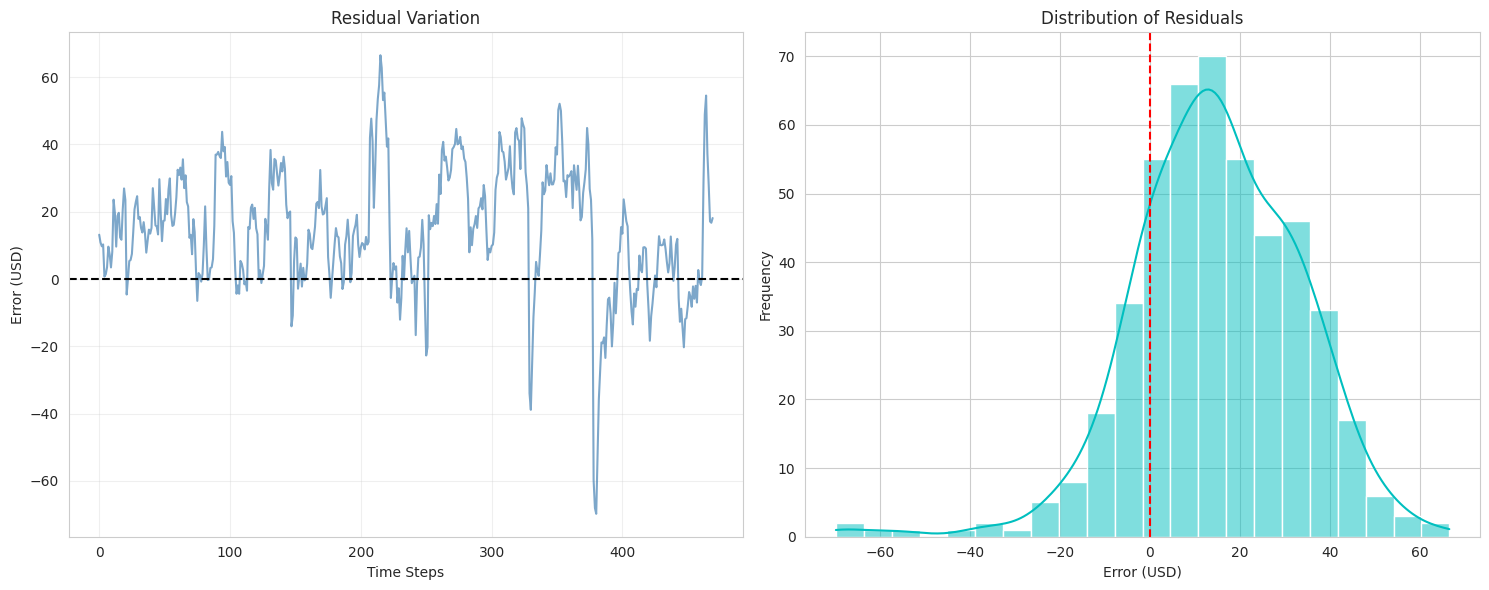

Residual Mean: 14.7619
Residual Std Dev: 18.4514


In [ ]:
# calculate the residuals of LSTM model
residuals = y_test_lstm.flatten() - y_pred_lstm.flatten()

plt.figure(figsize=(15, 6))

# 1. residual variation over time (heteroscedasticity)
plt.subplot(1, 2, 1)
plt.plot(residuals, color='steelblue', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Variation')
plt.xlabel('Time Steps')
plt.ylabel('Error (USD)')
plt.grid(True, alpha=0.3)

# 2. histogram of residual distribution (normality)
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='c')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribution of Residuals')
plt.xlabel('Error (USD)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Residual Mean: {np.mean(residuals):.4f}")
print(f"Residual Std Dev: {np.std(residuals):.4f}")

Analysis:

*   The residual mean of 14.76 USD indicates a slight underestimation by LSTM. While an ideal residual mean should converge to zero, the current results show that the predicted curve consistently sits slightly below the actual price level.

*   The residual standard deviation stands at 18.45 USD. Relative to the stock price range of 400-500 USD, this implies most errors fall within a ±5% margin, proving the previous results. The distribution plot exhibits a broad spread, suggesting higher variance in predictions during periods of intense market volatility.

*   According to the histogram of Residuals Distribution, the errors follow an approximately normal distribution, albeit with a slight rightward shift (corresponding to the positive mean). This near-normality displays that the LSTM has captured the primary price drivers, with the remaining errors consisting mostly of stochastic noise.

*   Noticeable outliers are visible at both ends of the histogram, with residuals occasionally hitting +80 or -60. This reflects the fat-tail phenomenon in financial markets, where the model shows limited predictive power for extreme price fluency.

*   In the Residual Variation plot, the error exhibits non-stationarity over time steps, which indicates the prediction of LSTM reacts with a temporal lag.

### ARIMAX


In [ ]:
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

Since the four feature columns originally selected did not perform well on the ARIMAX model, only two of them ('Relative_Volume', 'Volatility100') were retained for training.

In [ ]:
model_df = df.copy()

# target in log scale
model_df['Target'] = np.log(model_df['Close'])
features = ['Relative_Volume', 'Volatility100']

subset = model_df[features + ['Target', 'Close']].dropna().copy()

X = subset[features]
y = subset['Target']
close_actual = subset['Close']

print("Subset shape:", subset.shape)
display(subset.head())

Subset shape: (2499, 4)


,Relative_Volume,Volatility100,Target,Close
Date,,,,
2016-03-15,0.456077,5.356133,3.644981,38.282059
2016-03-16,0.808860,5.275995,3.665300,39.067852
2016-03-17,0.485767,5.157329,3.675892,39.483864
2016-03-18,0.881157,5.041180,3.668607,39.197277
2016-03-21,0.647685,4.947343,3.660081,38.864471


### Train-test split

In [ ]:
split_idx = int(len(X) * 0.8)

train_X_raw = X.iloc[:split_idx]
train_y_raw = y.iloc[:split_idx]
train_close_raw = close_actual.iloc[:split_idx]

test_X_raw = X.iloc[split_idx:]
test_y_raw = y.iloc[split_idx:]
test_close_raw = close_actual.iloc[split_idx:]

print("Train size:", len(train_X_raw))
print("Test size:", len(test_X_raw))
print("Test start date:", test_X_raw.index[0].date())
print("Test end date:", test_X_raw.index[-1].date())


Train size: 1999
Test size: 500
Test start date: 2024-02-23
Test end date: 2026-02-20


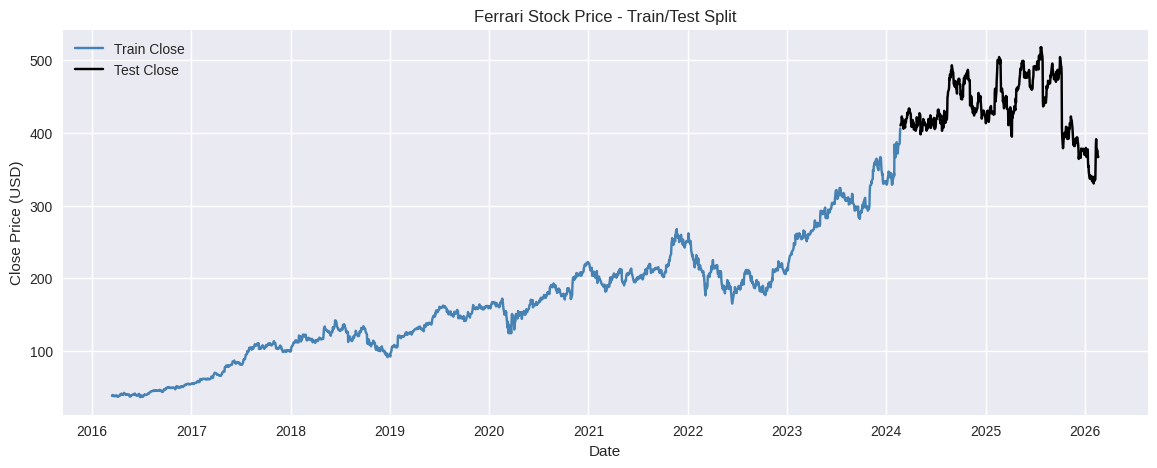

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(train_close_raw.index, train_close_raw, label='Train Close', color='steelblue')
plt.plot(test_close_raw.index, test_close_raw, label='Test Close', color='black')
plt.title('Ferrari Stock Price - Train/Test Split')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.show()


The figure shows that the dataset was split chronologically into training and testing sets, which is appropriate for time-series forecasting. The training set captures Ferrari's long-term upward trend from 2016 to early 2024, while the test set covers a more volatile period with high-price fluctuations followed by a noticeable decline. This indicates that the test period is more challenging to predict, since it contains a shift in market behavior compared with the earlier training period.


### Fit Auto-ARIMAX

In [ ]:
arimax_model = auto_arima(
    y=train_y_raw,
    X=train_X_raw,
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    d=None,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    information_criterion='aic'
)

print(arimax_model.summary())
print("Best order:", arimax_model.order)


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-10333.692, Time=0.43 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-10344.042, Time=0.32 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-10343.787, Time=1.93 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-10328.396, Time=0.67 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-10342.125, Time=0.73 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-10342.100, Time=0.44 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-10340.112, Time=1.05 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-10337.585, Time=0.45 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 6.066 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1999
Model:               SARIMAX(1, 1, 0)   Log Likelihood                5177.021
Date:                Fri, 27 Mar 2026   AIC                         -10344.042
Time:               

The stepwise search selected ARIMAX(1,1,0) with intercept as the best model based on AIC. This indicates that the log-transformed closing price series requires first-order differencing and still retains a weak first-order autoregressive structure. Among the exogenous variables, Volatility100 is statistically significant, while Relative_Volume is not. The Ljung-Box test suggests that residual autocorrelation is not a problem, indicating that the model captures the main linear temporal dependence.

In [ ]:
predictions_log = []
model = arimax_model

for i in range(len(test_y_raw)):
    current_X = test_X_raw.iloc[i].values.reshape(1, -1)

    pred = model.predict(n_periods=1, X=current_X)
    pred_value = np.asarray(pred)[0]
    predictions_log.append(pred_value)

    true_y = test_y_raw.iloc[i]
    model.update(true_y, X=current_X)

    if (i + 1) % 50 == 0:
        print(f"Progress: {i+1}/{len(test_y_raw)}")


Progress: 50/500
Progress: 100/500
Progress: 150/500
Progress: 200/500
Progress: 250/500
Progress: 300/500
Progress: 350/500
Progress: 400/500
Progress: 450/500
Progress: 500/500


In [ ]:
test_results = pd.DataFrame(index=test_y_raw.index)

test_results['Actual_Log_Close'] = test_y_raw.values
test_results['Predicted_Log_Close'] = predictions_log

test_results['Actual_Close'] = np.exp(test_results['Actual_Log_Close'])
test_results['Predicted_Close'] = np.exp(test_results['Predicted_Log_Close'])

display(test_results.head())

,Actual_Log_Close,Predicted_Log_Close,Actual_Close,Predicted_Close
Date,,,,
2024-02-23,6.016522,6.009376,410.149506,407.229287
2024-02-26,6.024326,6.020929,413.363068,411.961171
2024-02-27,6.029037,6.028622,415.314911,415.142482
2024-02-28,6.046099,6.034978,422.461731,417.789672
2024-02-29,6.037216,6.050217,418.725647,424.204980


In [ ]:
mae = mean_absolute_error(test_results['Actual_Close'], test_results['Predicted_Close'])
mse = mean_squared_error(test_results['Actual_Close'], test_results['Predicted_Close'])
rmse = np.sqrt(mse)
mape = np.mean(
    np.abs((test_results['Actual_Close'] - test_results['Predicted_Close']) / test_results['Actual_Close'])
) * 100

actual_diff = test_results['Actual_Close'].diff().dropna()
pred_diff = test_results['Predicted_Close'].diff().dropna()
mda = np.mean(np.sign(actual_diff) == np.sign(pred_diff)) * 100

print('--- ARIMAX Model Evaluation ---')
print(f'MAE  : {mae:.4f} USD')
print(f'MSE  : {mse:.4f}')
print(f'RMSE : {rmse:.4f} USD')
print(f'MAPE : {mape:.4f} %')
print(f'MDA  : {mda:.2f}%')


--- ARIMAX Model Evaluation ---
MAE  : 5.6236 USD
MSE  : 71.4574
RMSE : 8.4532 USD
MAPE : 1.3074 %
MDA  : 45.29%


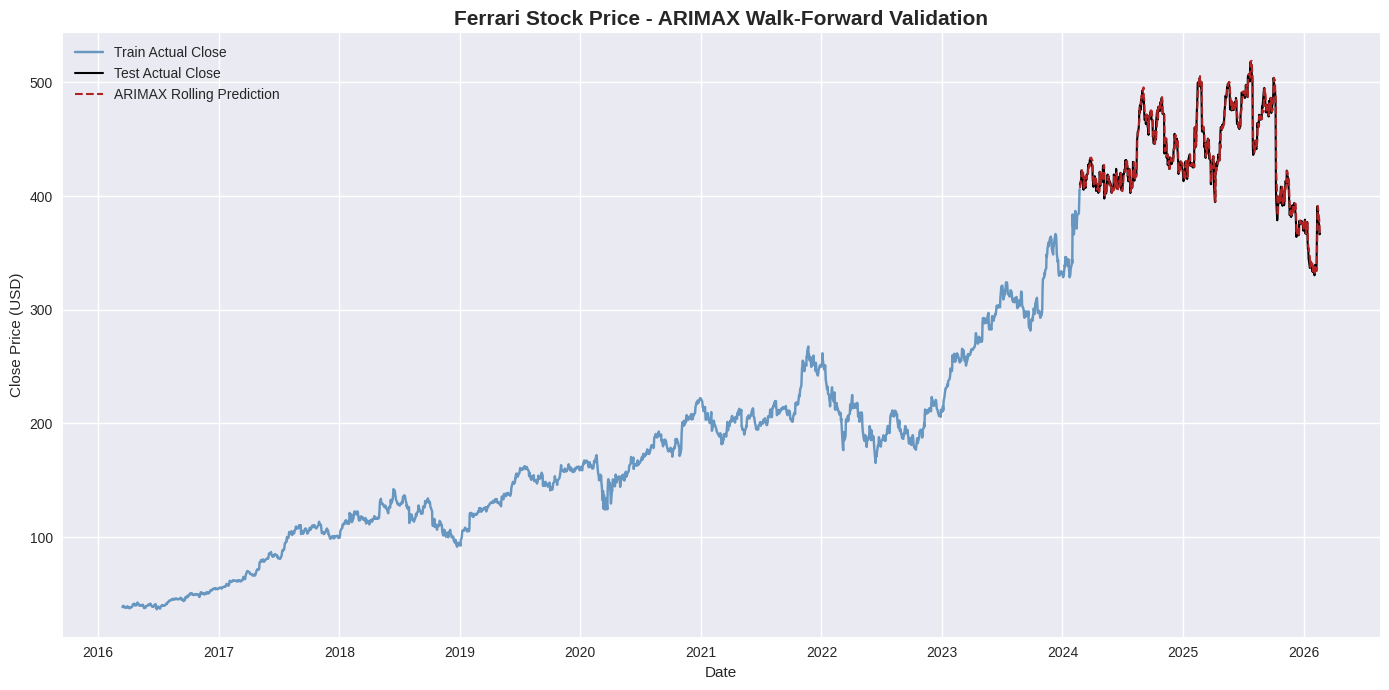

In [ ]:
plt.figure(figsize=(14,7))
plt.plot(train_close_raw.index, train_close_raw, label='Train Actual Close', color='steelblue', alpha=0.8)
plt.plot(test_results.index, test_results['Actual_Close'], label='Test Actual Close', color='black', linewidth=1.5)
plt.plot(test_results.index, test_results['Predicted_Close'], label='ARIMAX Rolling Prediction', color='firebrick', linestyle='--', linewidth=1.5)

plt.title('Ferrari Stock Price - ARIMAX Walk-Forward Validation', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

The walk-forward validation plot shows that the ARIMAX model tracks the actual Ferrari closing prices closely throughout the test period. The predicted series follows both the high-price fluctuations and the later downward movement without collapsing into a flat forecast, indicating that the model adapts well to changing market conditions. This suggests that the ARIMAX model performs strongly in price-level forecasting.

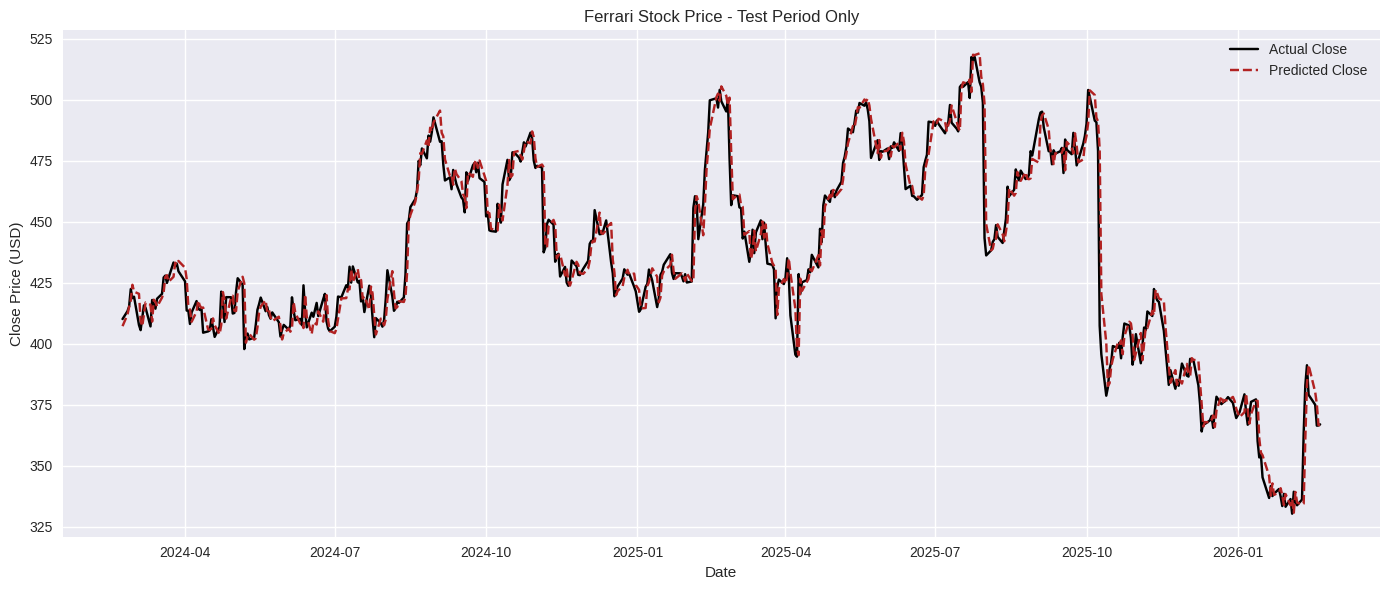

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(test_results.index, test_results['Actual_Close'], label='Actual Close', color='black')
plt.plot(test_results.index, test_results['Predicted_Close'], label='Predicted Close', color='firebrick', linestyle='--')

plt.title('Ferrari Stock Price - Test Period Only')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

The test-period plot shows that the ARIMAX predictions closely track the actual Ferrari closing prices over most of the evaluation horizon. The predicted series is able to follow the major upward movements, pullbacks, and the sharp decline in late 2025, indicating strong performance in modeling the overall price level. Unlike the earlier plain ARIMA model, the forecast does not collapse into a flat line, suggesting that the inclusion of exogenous variables and walk-forward updating improves adaptability.

### Residual analysis

Residual Mean: -0.5829
Residual Std Dev: 8.4331


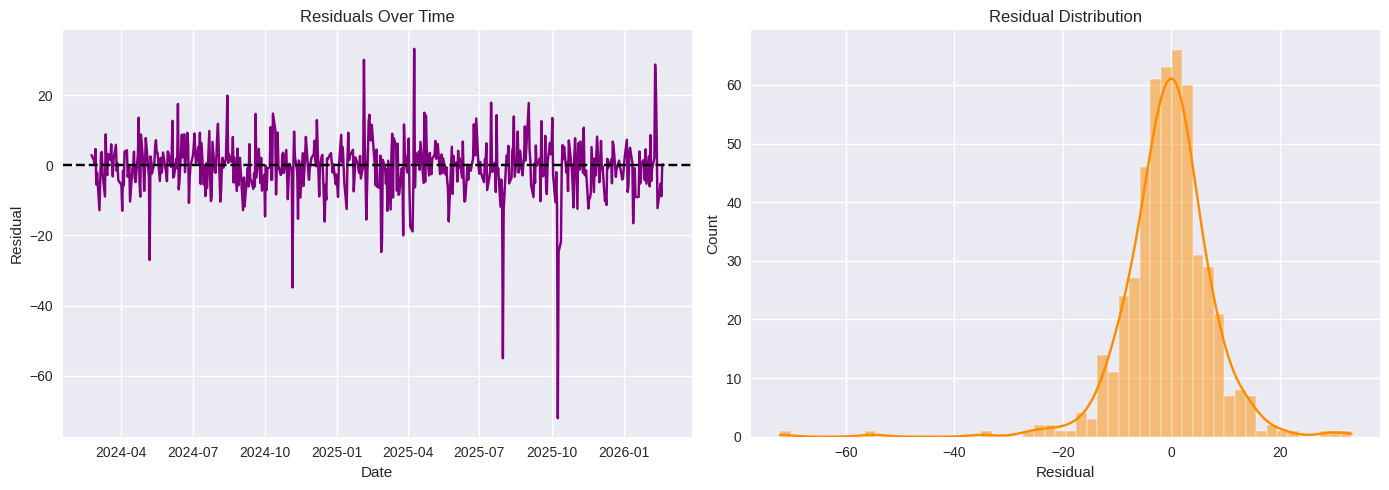

In [ ]:
test_results['Residual'] = test_results['Actual_Close'] - test_results['Predicted_Close']
residuals = test_results['Residual']

print(f"Residual Mean: {np.mean(residuals):.4f}")
print(f"Residual Std Dev: {np.std(residuals):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(test_results.index, residuals, color='purple')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Residuals Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residual')

sns.histplot(residuals, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

The residual mean is -0.5829, which is close to zero, indicating that the ARIMAX model does not show strong systematic bias. The negative sign suggests a slight tendency to overestimate the stock price on average, but the magnitude is very small relative to the overall price level. The residual standard deviation is 8.4331, showing that the forecast errors are reasonably stable and generally remain within a moderate range. Overall, these results suggest that the model provides accurate and consistent predictions over the test period.


The residual plot shows that most errors fluctuate around zero, suggesting that the ARIMAX model does not suffer from strong systematic bias. However, several large spikes are visible, indicating that the model performs poorly on a few extreme trading days. The residual histogram is centered near zero, but the distribution is clearly not perfectly symmetric and exhibits heavy tails, especially on the negative side. This implies that while the model performs reasonably well under normal market conditions, it is less capable of capturing abrupt and extreme stock price movements.


## Compare two models

In [ ]:
comparison_df = pd.DataFrame({
    'MAE (USD)': [mae, mae_lstm],
    'MSE': [mse, mse_lstm],
    'RMSE (USD)': [rmse, rmse_lstm],
    'MAPE (%)': [mape, mape_lstm],
    'MDA (%)': [mda, mda_lstm * 100 if mda_lstm < 1 else mda_lstm]
}, index=['ARIMAX', 'LSTM'])

comparison_df = comparison_df.round(4)
display(comparison_df)


,MAE (USD),MSE,RMSE (USD),MAPE (%),MDA (%)
ARIMAX,5.6236,71.4574,8.4532,1.3074,45.2906
LSTM,18.9782,558.3661,23.6298,4.2331,48.4009


The evaluation results show that ARIMAX significantly outperforms LSTM in price level prediction. Its MAE, RMSE, and MAPE are all significantly lower than LSTM, indicating that ARIMAX can more accurately track the actual closing price changes of Ferrari stock. In particular, the 1.31% MAPE indicates that ARIMAX has high price prediction accuracy during the test period. In contrast, LSTM's error rate is significantly higher, indicating its weaker ability to fit price levels under the experimental settings.

However, in terms of directional accuracy (MDA), LSTM's result is slightly higher than ARIMAX (48.40% vs 45.29%). This shows that although LSTM is not as accurate as ARIMAX in predicting actual price values, it has a slight advantage in identifying short-term price direction. However, neither model's MDA reaches a high level, indicating that their ability to predict short-term direction is relatively limited.

In summary, ARIMAX is more suitable for predicting price levels of Ferrari stock, while LSTM did not demonstrate a stronger predictive advantage over ARIMAX in this experiment.